In [4]:
import numpy as np 
import pandas as pd  
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings("ignore")

In [5]:
df = pd.read_csv("IPL.csv")

In [6]:
df.head()

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20
1,2,"March 27,2022","Brabourne Stadium, Mumbai",Delhi,Mumbai,Group,Delhi,Field,177,5,179,6,Delhi,Wickets,4,Kuldeep Yadav,Ishan Kishan,81,Kuldeep Yadav,3--18
2,3,"March 27,2022","Dr DY Patil Sports Academy, Mumbai",Banglore,Punjab,Group,Punjab,Field,205,2,208,5,Punjab,Wickets,5,Odean Smith,Faf du Plessis,88,Mohammed Siraj,2--59
3,4,"March 28,2022","Wankhede Stadium, Mumbai",Gujarat,Lucknow,Group,Gujarat,Field,158,6,161,5,Gujarat,Wickets,5,Mohammed Shami,Deepak Hooda,55,Mohammed Shami,3--25
4,5,"March 29,2022","Maharashtra Cricket Association Stadium,Pune",Hyderabad,Rajasthan,Group,Hyderabad,Field,210,6,149,7,Rajasthan,Runs,61,Sanju Samson,Aiden Markram,57,Yuzvendra Chahal,3--22


In [8]:
df.columns

Index(['match_id', 'date', 'venue', 'team1', 'team2', 'stage', 'toss_winner',
       'toss_decision', 'first_ings_score', 'first_ings_wkts',
       'second_ings_score', 'second_ings_wkts', 'match_winner', 'won_by',
       'margin', 'player_of_the_match', 'top_scorer', 'highscore',
       'best_bowling', 'best_bowling_figure'],
      dtype='object')

In [9]:
df.shape

(74, 20)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 74 entries, 0 to 73
Data columns (total 20 columns):
 #   Column               Non-Null Count  Dtype 
---  ------               --------------  ----- 
 0   match_id             74 non-null     int64 
 1   date                 74 non-null     object
 2   venue                74 non-null     object
 3   team1                74 non-null     object
 4   team2                74 non-null     object
 5   stage                74 non-null     object
 6   toss_winner          74 non-null     object
 7   toss_decision        74 non-null     object
 8   first_ings_score     74 non-null     int64 
 9   first_ings_wkts      74 non-null     int64 
 10  second_ings_score    74 non-null     int64 
 11  second_ings_wkts     74 non-null     int64 
 12  match_winner         74 non-null     object
 13  won_by               74 non-null     object
 14  margin               74 non-null     int64 
 15  player_of_the_match  74 non-null     object
 16  top_scorer

In [ ]:
#MOST NUMBER OF MATCHES WON BY TEAMS 

Text(0.5, 1.0, 'MOST MATCH WIN BY TEAM')

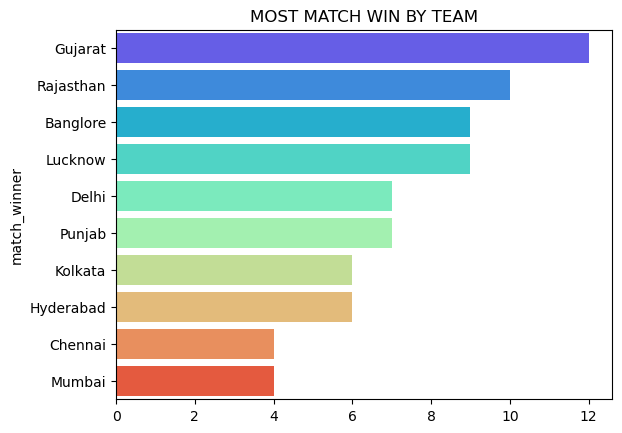

In [17]:
A= df['match_winner'].value_counts()
sns.barplot(y=A.index , x= A.values, palette='rainbow')
plt.title("MOST MATCH WIN BY TEAM")

In [ ]:
#AFTER TOSS WHAT MOST TEAM CHOOSE BAT OR BOWL

<Axes: xlabel='toss_decision', ylabel='count'>

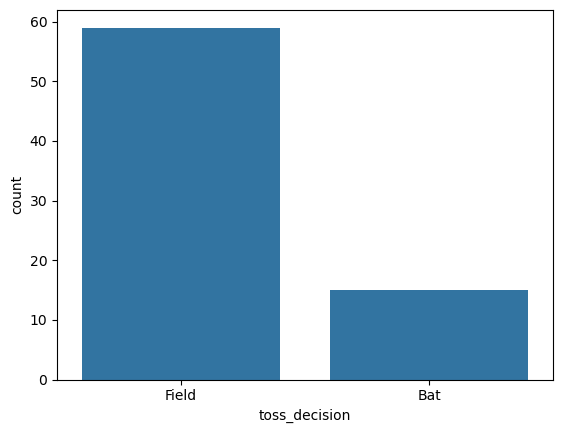

In [36]:
sns.countplot(x = df['toss_decision'])

In [35]:
#MOST PLAYER OF THE MATCH AWARDS 


In [46]:
potm = df['player_of_the_match'].value_counts().head(10)

Text(0.5, 1.0, 'MOST POTM WINNER')

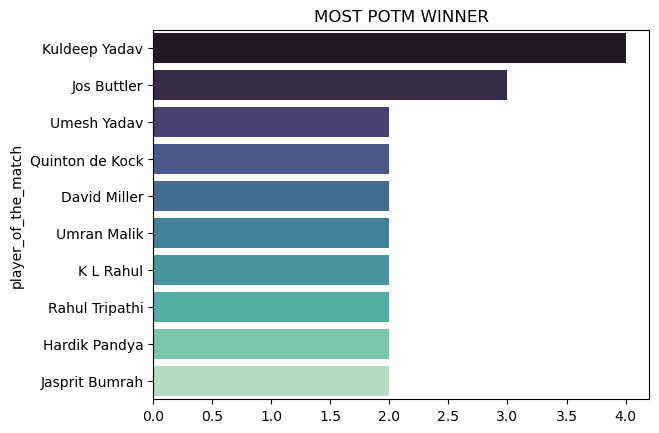

In [48]:
sns.barplot(x=potm.values,y=potm.index,palette='mako')
plt.title("MOST POTM WINNER")

In [49]:
#TOP SCORER 

In [63]:
A = df.groupby('top_scorer')['highscore'].sum()

In [69]:
high = A.nlargest()

<Axes: ylabel='top_scorer'>

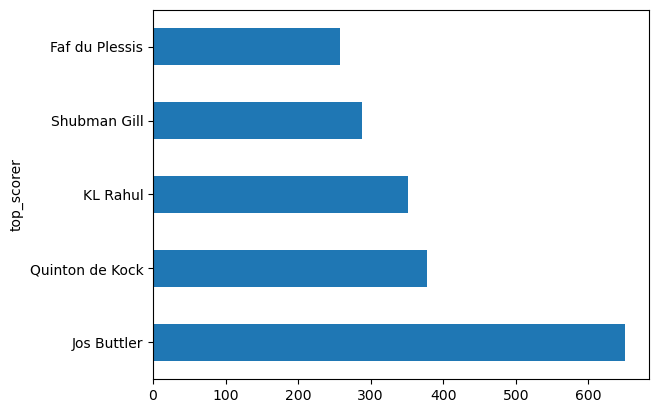

In [72]:
high.plot(kind='barh')

In [73]:
#10 BEST BOWLONG FIGURES 

In [74]:
df.head(1)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,second_ings_score,second_ings_wkts,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure
0,1,"March 26,2022","Wankhede Stadium, Mumbai",Chennai,Kolkata,Group,Kolkata,Field,131,5,133,4,Kolkata,Wickets,6,Umesh Yadav,MS Dhoni,50,Dwayne Bravo,3--20


In [80]:
df['highest_wicket'] = df['best_bowling_figure'].apply(lambda x: x.split('--')[0])

In [81]:
df['highest_wicket'] = df['higest_wicket'].astype(int)

In [89]:
top_bowler = df.groupby('best_bowling')['highest_wicket'].sum().sort_values(ascending = False).head(10)

best_bowling
Yuzvendra Chahal     17
Kuldeep Yadav        11
Rashid Khan          11
Jasprit Bumrah       11
Avesh Khan           10
Josh Hazlewood       10
Kagiso Rabada        10
Wanindu Hasaranga     9
Umran Malik           9
T Natarajan           8
Name: highest_wicket, dtype: int32

<Axes: ylabel='best_bowling'>

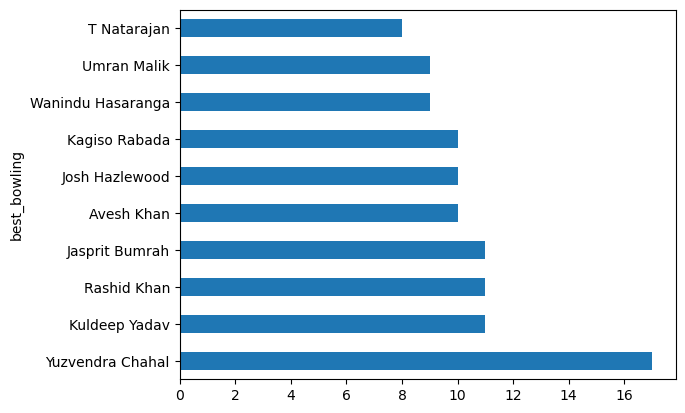

In [91]:
top_bowler.plot(kind = 'barh')

In [96]:
# WHO WON THE HIGHEST MARGIN BY RUNS 

In [116]:
WR = df[df['won_by'] == 'Runs']


In [115]:
WR.sort_values(by='margin',ascending=False).head(1)

,match_id,date,venue,team1,team2,stage,toss_winner,toss_decision,first_ings_score,first_ings_wkts,...,match_winner,won_by,margin,player_of_the_match,top_scorer,highscore,best_bowling,best_bowling_figure,higest_wicket,highest_wicket
54,55,"May 8,2022","Dr DY Patil Sports Academy, Mumbai",Chennai,Delhi,Group,Delhi,Field,208,6,...,Chennai,Runs,91,Devon Conway,Devon Conway,87,Moeen Ali,3--13,3,3


In [117]:
# WHICH PLAYER HAS THE HIGHEST INDIVIDUAL SCORE 

In [144]:
IS = df[['top_scorer','highscore']].sort_values(by='highscore',ascending=False)

In [146]:
IS.head(1)

,top_scorer,highscore
65,Quinton de Kock,140
